# Notebook 03: EDA Geoespacial das Bases: Motivação das Métricas Intrínsecas

Este notebook realiza a análise exploratória (EDA) das duas bases de dados (CNEFE e BHMap) e das métricas de coordenada, motivando e validando empiricamente as **métricas intrínsecas** do índice GCI, aquelas que não requerem padrão-ouro externo e podem ser calculadas em qualquer município com o CNEFE.

**O que este notebook demonstra:**
- **CDI** (Coordinate Duplication Index): reflete estruturalmente a metodologia de coleta do IBGE, GPS por edifício, não por unidade. CDI mediano no Hipercentro = 55; no Barreiro = 1.
- **CCR** (Coordinate Containment Rate): captura inconsistências entre coordenada GPS e setor censitário declarado sem depender do BHMap. CCR global = 75,9%; Hipercentro = 75,8%.
- **DRS** (Distance to Road Segment): mede aderência à rede viária como proxy independente de precisão. Mediana = 4,6m; P90 = 19,3m; 98,1% dentro de 50m.

**Hipóteses abordadas:**
- **H1** (Apartamentos × GCI): CDI mediano de apartamentos >> 1 vs. casas = 1, mecanismo central do PCI_empirico
- **H2** (NV_GEO_COORD × erro): distribuição de NV por espécie e regional estabelece base do LCI
- **H3** (Dependência espacial): padrão geográfico de CDI, CCR e DRS por setor censitário antecipa autocorrelação (Moran I=0,43, testado em NB11)

**Escopo:** este notebook trata apenas das duas bases e das métricas intrínsecas de coordenada. A EDA das camadas de contexto BHMap (edificação, área de risco, IVS, lotes CTM e cadastro imobiliário) e o screening de covariáveis estão no NB08, que operacionaliza o contexto urbano para H4 e demais hipóteses contextuais testadas em NB09 a NB12.

**Seções:** 1 Composição e Completude | 2 CDI, CCR, DRS | 3 BHMap Padrão-Ouro | 4 Mapas Coropléticos

In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, warnings
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
from src.metrics import calculate_cdi, calculate_ccr, calculate_drs, calculate_csi, calculate_pci

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETA_REGIONAL = {
    'BARREIRO': '#e41a1c', 'CENTRO-SUL': '#377eb8', 'HIPERCENTRO': '#ff7f00',
    'LESTE': '#4daf4a', 'NORDESTE': '#984ea3', 'NOROESTE': '#a65628',
    'NORTE': '#f781bf', 'OESTE': '#999999', 'PAMPULHA': '#66c2a5',
    'VENDA NOVA': '#fc8d62',
}

## Setup: Fontes de Dados

Este notebook trabalha com cinco camadas de dados, carregadas do pipeline v2:
- `cnefe_bh.parquet`: CNEFE 2022 filtrado para BH, base bruta de 1,18M endereços
- `bhmap_bh_existente.parquet`: BHMap filtrado por `EXISTENCIA="Sim"`, padrão-ouro com 515.953 pontos
- `cnefe_master_metrics.parquet`: dataset consolidado com todas as métricas
- `cnefe_coordinate_metrics.parquet`: métricas intrínsecas de coordenada (CDI, CCR, DRS)
- Camadas contextuais: regionais e setores censitários (geometrias para joins espaciais)

In [2]:
# Carregar dados
cnefe = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_bh.parquet')
bhmap_exist = gpd.read_parquet(config.PROCESSED_DIR / 'bhmap_bh_existente.parquet')
cnefe_matched = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_matched.parquet')
regionais = gpd.read_file(config.REGIONAIS_SHP)
regionais = regionais.rename(columns={'NOME': 'NOME_REGIO'})
setores = gpd.read_file(config.SETOR_CENSITARIO_SHP)
vias = gpd.read_file(config.CLASSIFICACAO_VIARIA_SHP)

cnefe = cnefe.drop(columns=[c for c in ['NOME_REGIO'] if c in cnefe.columns])
bhmap_exist = bhmap_exist.drop(columns=[c for c in ['NOME_REGIO'] if c in bhmap_exist.columns])

for gdf_ref in [cnefe, cnefe_matched, setores]:
    if gdf_ref.crs.to_epsg() != 31983:
        gdf_ref = gdf_ref.to_crs(config.TARGET_CRS)
vias = vias[vias.geometry.notna() & ~vias.geometry.is_empty].copy()
if vias.crs.to_epsg() != 31983:
    vias = vias.to_crs(config.TARGET_CRS)

print(f'CNEFE:           {len(cnefe):>10,} registros')
print(f'CNEFE matched:   {len(cnefe_matched):>10,} registros')
print(f'BHMap existente: {len(bhmap_exist):>8,} registros')
print(f'Regionais:       {len(regionais):>10,} polígonos')
print(f'Setores:         {len(setores):>10,} polígonos')
print(f'Vias:            {len(vias):>10,} segmentos')

CNEFE:            1,180,102 registros
CNEFE matched:    1,172,902 registros
BHMap existente:  515,953 registros
Regionais:               10 polígonos
Setores:              5,166 polígonos
Vias:                54,404 segmentos


## 1b. Cálculo das Métricas Intrínsecas de Coordenada

As métricas abaixo são calculadas sobre os 1,18 M registros do CNEFE bruto, sem necessidade do BHMap. Por serem **intrínsecas**, reproduzem-se em qualquer município com CNEFE.

| Métrica | O que mede | Como é calculada |
|---|---|---|
| **CDI** | Quantos endereços compartilham a mesma coordenada GPS (tolerância 1 m) | Arredondamento de (x, y) a 1 m + contagem de duplicatas |
| **PCI_empirico** | Penalização proporcional ao colapso de coordenadas | 1 / CDI |
| **CCR** | Ponto dentro do setor censitário declarado? | Sjoin ponto–polígono com setores |
| **DRS** | Distância ao trecho de logradouro mais próximo | Sjoin_nearest com rede viária |
| **CSI** | Distância ao centróide do setor declarado | Distância euclidiana ao centróide do setor correspondente |

O resultado é salvo em `cnefe_coordinate_metrics.parquet` e consumido por NB05 (cálculo do GCI) e NB06 (consolidação de edifícios).

In [3]:
print("Calculando CDI e PCI_empirico...")
cdi_df = calculate_cdi(cnefe, coord_precision_m=1)
print(f"  CDI=1 (coord única): {(cdi_df['cdi'] == 1).sum():,} ({(cdi_df['cdi'] == 1).mean()*100:.1f}%)")
print(f"  CDI máximo: {cdi_df['cdi'].max()}")

print("\nCalculando CCR (ponto dentro do setor declarado)...")
ccr = calculate_ccr(cnefe, setores, setor_col_cnefe='COD_SETOR', setor_col_poly='COD_SETOR')
print(f"  Dentro do setor: {ccr.sum():,} ({ccr.mean()*100:.1f}%)")

print("\nCalculando DRS (distância à via mais próxima)...")
drs = calculate_drs(cnefe, vias, batch_size=50_000)
print(f"  Mediana: {drs.median():.1f}m | P90: {drs.quantile(0.90):.1f}m | >50m: {(drs > 50).sum():,}")

print("\nCalculando CSI (distância ao centróide do setor)...")
csi = calculate_csi(cnefe, setores, setor_col_cnefe='COD_SETOR', setor_col_poly='COD_SETOR')
print(f"  Mediana: {csi.median():.1f}m")

coord_m = pd.DataFrame({
    'COD_UNICO_ENDERECO': cnefe['COD_UNICO_ENDERECO'],
    'cdi':          cdi_df['cdi'],
    'pci_empirico': cdi_df['pci_empirico'],
    'ccr':          ccr.astype(int),
    'drs':          drs,
    'csi':          csi,
}, index=cnefe.index)

coord_m.to_parquet(config.PROCESSED_DIR / 'cnefe_coordinate_metrics.parquet')
print(f"\nSalvo: cnefe_coordinate_metrics.parquet ({len(coord_m):,} registros)")

# Juntar coord_m ao matched para análises regionalizadas neste notebook
metrics = cnefe_matched.join(coord_m[['cdi', 'pci_empirico', 'ccr', 'drs', 'csi']], how='left')
metrics['PCI_arbitrario'] = calculate_pci(metrics)
print(f"metrics (matched + coord): {len(metrics):,} registros")

Calculando CDI e PCI_empirico...


  CDI=1 (coord única): 664,460 (56.3%)
  CDI máximo: 287

Calculando CCR (ponto dentro do setor declarado)...


  Dentro do setor: 895,362 (75.9%)

Calculando DRS (distância à via mais próxima)...


  Distância às vias:   0%|          | 0/24 [00:00<?, ?lote/s]

  Mediana: 4.6m | P90: 19.3m | >50m: 22,151

Calculando CSI (distância ao centróide do setor)...


  Mediana: 93.1m



Salvo: cnefe_coordinate_metrics.parquet (1,180,102 registros)
metrics (matched + coord): 1,172,902 registros


CNEFE BH: 1.180.102 registros | BHMap (EXISTENCIA=Sim): 515.953 pontos | Master metrics v2: 1.172.902 registros (99,4% do CNEFE com par BHMap válido). Os 7.200 sem par (0,61%) concentram-se em periferias com cobertura incompleta.

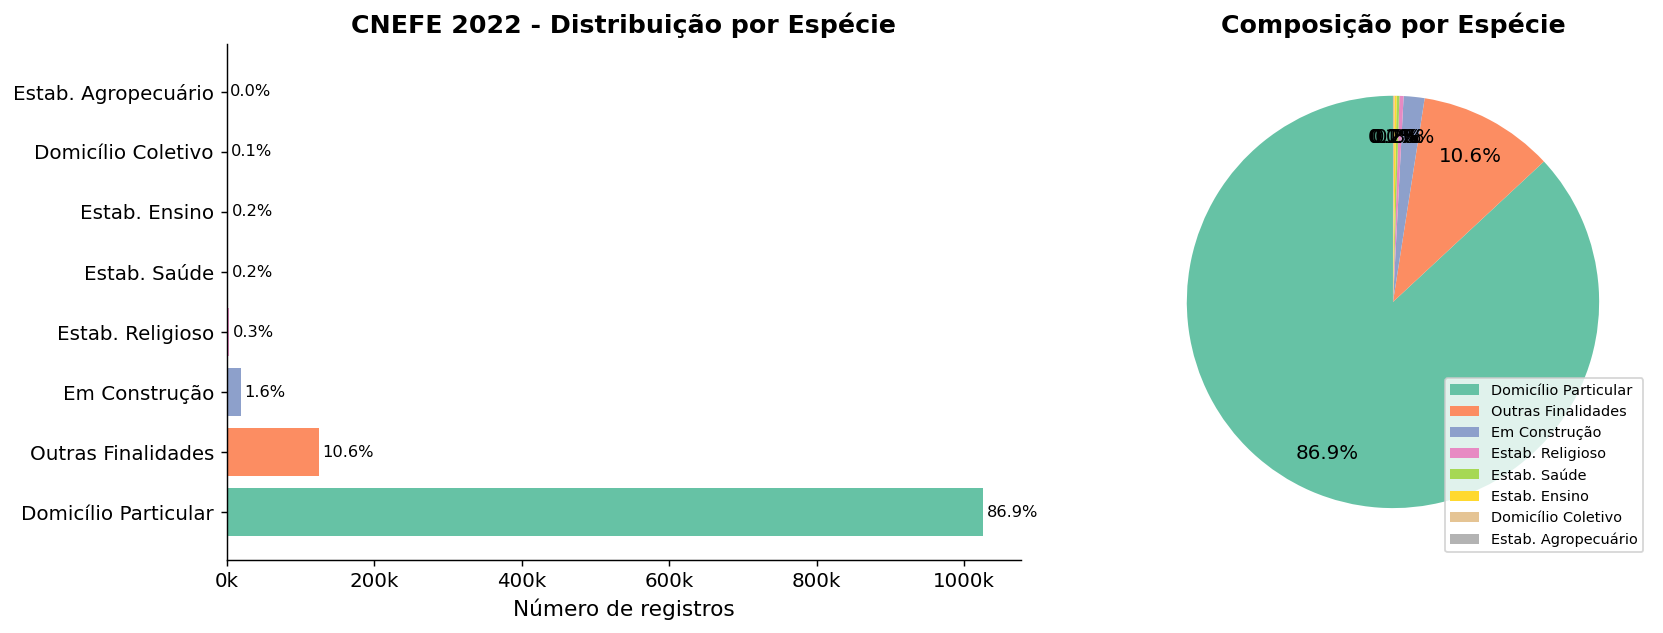

,N,% do total
Espécie,,
Domicílio Particular,"1,025,822",86.9%
Outras Finalidades,"125,268",10.6%
Em Construção,"19,297",1.6%
Estab. Religioso,"3,805",0.3%
Estab. Saúde,"2,483",0.2%
Estab. Ensino,"2,037",0.2%
Domicílio Coletivo,"1,348",0.1%
Estab. Agropecuário,42,0.0%


In [4]:
# 1.1 Distribuição por espécie
esp_map = config.ESPECIE_MAP
cnefe['especie_label'] = cnefe['COD_ESPECIE'].map(esp_map).fillna('Desconhecido')

esp_counts = cnefe['especie_label'].value_counts()
esp_pcts = esp_counts / len(cnefe) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
ax = axes[0]
bars = ax.barh(esp_counts.index, esp_counts.values, color=sns.color_palette('Set2', len(esp_counts)))
ax.set_xlabel('Número de registros')
ax.set_title('CNEFE 2022 - Distribuição por Espécie', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for bar, pct in zip(bars, esp_pcts.values):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

# Pizza
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    esp_counts.values, labels=None, autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(esp_counts)), startangle=90,
    pctdistance=0.8
)
ax.legend(wedges, esp_counts.index, loc='lower right', fontsize=8)
ax.set_title('Composição por Espécie', fontweight='bold')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_especie_dist.png', bbox_inches='tight')
plt.show()

esp_table = pd.DataFrame({'Espécie': esp_counts.index, 'N': esp_counts.values,
                           '% do total': esp_pcts.round(1).values}).set_index('Espécie')
display(esp_table.style
    .background_gradient(subset=['N'], cmap='Blues')
    .background_gradient(subset=['% do total'], cmap='YlGn')
    .format({'N': '{:,.0f}', '% do total': '{:.1f}%'})
    .set_caption('Distribuição do CNEFE 2022 por Espécie de Endereço'))

A predominância de domicílios particulares (~87%) confirma que a análise de qualidade do CNEFE é essencialmente residencial. A distinção tipológica interna (casa vs apartamento) é mais relevante que a distinção por espécie para as hipóteses de qualidade.

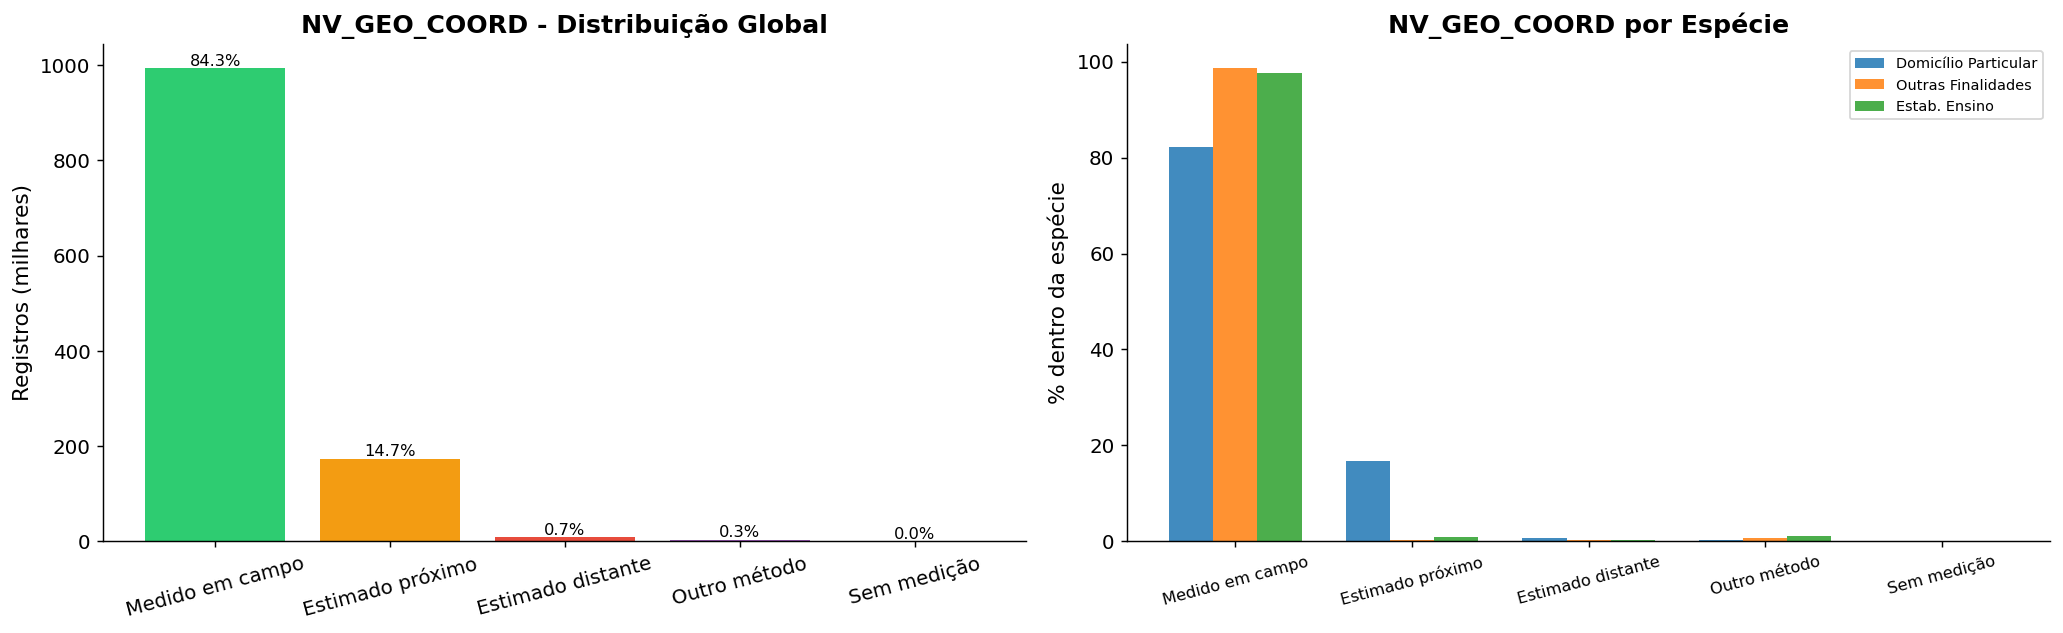

In [5]:
# 1.2 Distribuição de NV_GEO_COORD (global e por espécie)
nv_map = config.NV_GEO_MAP
cnefe['nv_label'] = cnefe['NV_GEO_COORD'].map(nv_map).fillna('Desconhecido')

# Global
nv_global = cnefe['NV_GEO_COORD'].value_counts().sort_index()
nv_labels_ordered = [nv_map.get(k, str(k)) for k in nv_global.index]
nv_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#95a5a6']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(nv_labels_ordered, nv_global.values / 1000,
              color=nv_colors[:len(nv_global)])
ax.set_ylabel('Registros (milhares)')
ax.set_title('NV_GEO_COORD - Distribuição Global', fontweight='bold')
for bar, val in zip(bars, nv_global.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val/len(cnefe)*100:.1f}%', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=15)

# Por espécie (top 3)
ax = axes[1]
top_especies = ['Domicílio Particular', 'Outras Finalidades', 'Estab. Ensino']
width = 0.25
x = np.arange(len(nv_global))
for i, esp in enumerate(top_especies):
    sub = cnefe[cnefe['especie_label'] == esp]
    nv_sub = sub['NV_GEO_COORD'].value_counts().reindex(nv_global.index, fill_value=0)
    pcts = nv_sub.values / len(sub) * 100
    ax.bar(x + i*width, pcts, width, label=esp, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(nv_labels_ordered, rotation=15, fontsize=9)
ax.set_ylabel('% dentro da espécie')
ax.set_title('NV_GEO_COORD por Espécie', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_nv_geo_dist.png', bbox_inches='tight')
plt.show()

NV=1 (GPS campo) domina (>79%), validando que a maioria dos registros tem coordenada de medição direta. NV=2 e NV=6 são minorias que degradam o LCI.

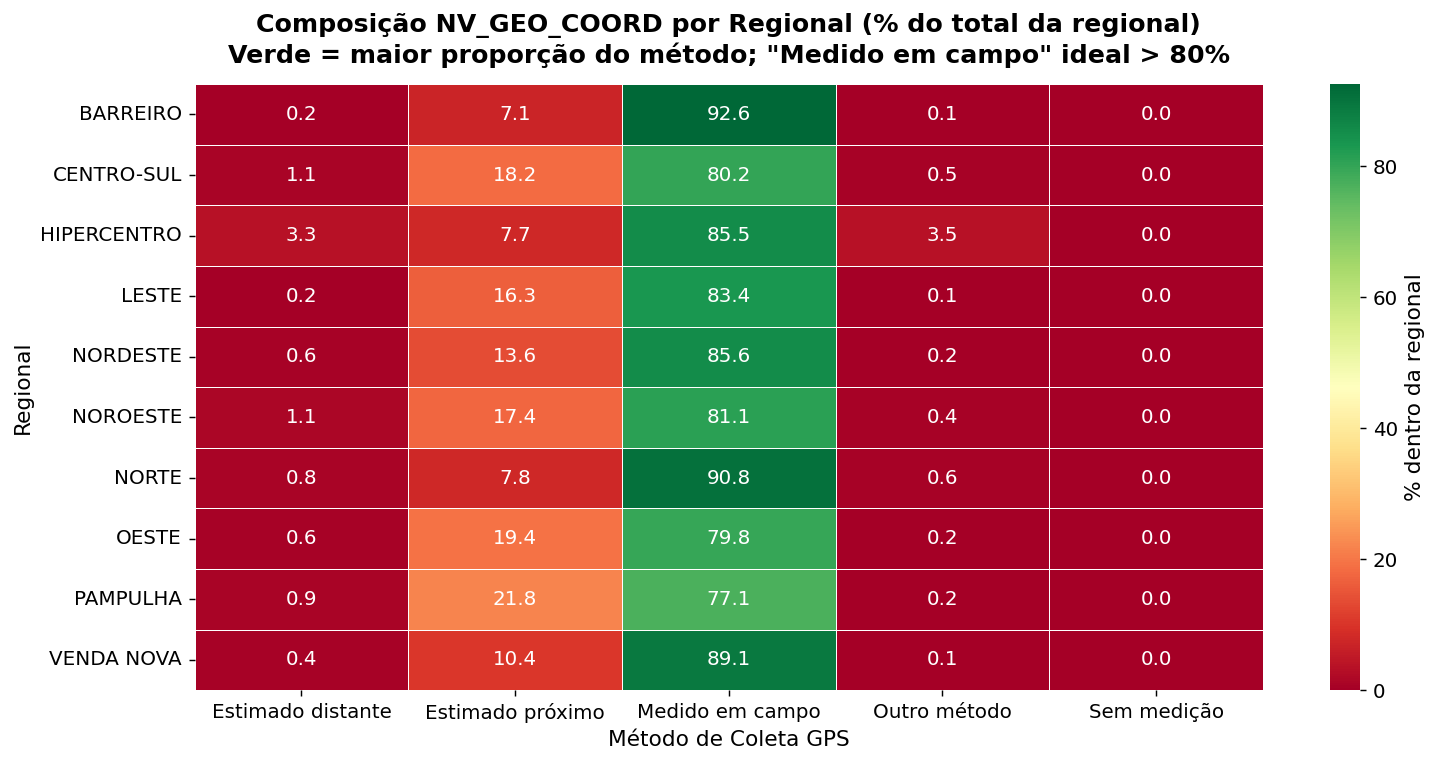

NV_GEO_COORD,Estimado distante,Estimado próximo,Medido em campo,Outro método,Sem medição
NOME_REGIO,,,,,
BARREIRO,0.2%,7.1%,92.6%,0.1%,0.0%
CENTRO-SUL,1.1%,18.2%,80.2%,0.5%,0.0%
HIPERCENTRO,3.3%,7.7%,85.5%,3.5%,0.0%
LESTE,0.2%,16.3%,83.4%,0.1%,0.0%
NORDESTE,0.6%,13.6%,85.6%,0.2%,0.0%
NOROESTE,1.1%,17.4%,81.1%,0.4%,0.0%
NORTE,0.8%,7.8%,90.8%,0.6%,0.0%
OESTE,0.6%,19.4%,79.8%,0.2%,0.0%
PAMPULHA,0.9%,21.8%,77.1%,0.2%,0.0%


In [6]:
# 1.3 NV_GEO_COORD por Regional (heatmap)
# Unir CNEFE com regional via spatial join
regionais_proj = regionais.to_crs(config.TARGET_CRS)
cnefe_reg = gpd.sjoin(cnefe, regionais_proj[['NOME_REGIO', 'geometry']],
                       how='left', predicate='within')
cnefe_reg = cnefe_reg[~cnefe_reg.index.duplicated(keep='first')]

# Tabela cruzada NV × Regional (% por regional)
ct = pd.crosstab(
    cnefe_reg['NOME_REGIO'],
    cnefe_reg['NV_GEO_COORD'].map(nv_map),
    normalize='index'
) * 100


fig, ax = plt.subplots(figsize=(12, 6))
# RdYlGn (sem _r): células com valor alto ficam verdes
# Para "Medido em campo" (bom): % alta → verde ✓
# Para métodos estimados (preocupante): % alta → verde (use como mapa de intensidade)
sns.heatmap(ct, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% dentro da regional'})
ax.set_title('Composição NV_GEO_COORD por Regional (% do total da regional)\n'
             'Verde = maior proporção do método; "Medido em campo" ideal > 80%',
             fontweight='bold', pad=12)
ax.set_xlabel('Método de Coleta GPS')
ax.set_ylabel('Regional')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_nv_regional_heatmap.png', bbox_inches='tight')
plt.show()
display(ct.round(1).style
    .background_gradient(cmap='RdYlGn', axis=None)
    .set_caption('NV_GEO_COORD por Regional (%)').format('{:.1f}%'))

O heatmap regionalizado mostra se há concentração geográfica de métodos menos precisos. Regionais verticalizadas (Hipercentro, Oeste) apresentam maior proporção de NV=2.

NV=1 (GPS em campo) domina em todas as espécies, mas a proporção varia: domicílios têm perfil mais limpo que estabelecimentos agropecuários e coletivos. A distribuição confirma que o LCI médio alto (0,965) é sustentado pela predominância de domicílios com GPS de campo.

## 2. Métricas de Coordenada: CDI, CCR e DRS

### 2.1 CDI: Coordinate Duplication Index: Justificativa Empírica Central

O CDI conta quantos endereços distintos compartilham a mesma coordenada GPS (tolerância 1m). É a métrica mais importante deste notebook: se apartamentos tiverem CDI sistematicamente maior, isso justifica substituir o PCI arbitrário (0,5 para apartamentos) pelo PCI empírico (1/CDI). O histograma em escala log e o boxplot por tipo revelam a distribuição de CDI. **Esta é a premissa empírica central da contribuição C2: PCI_empirico = 1/CDI.**

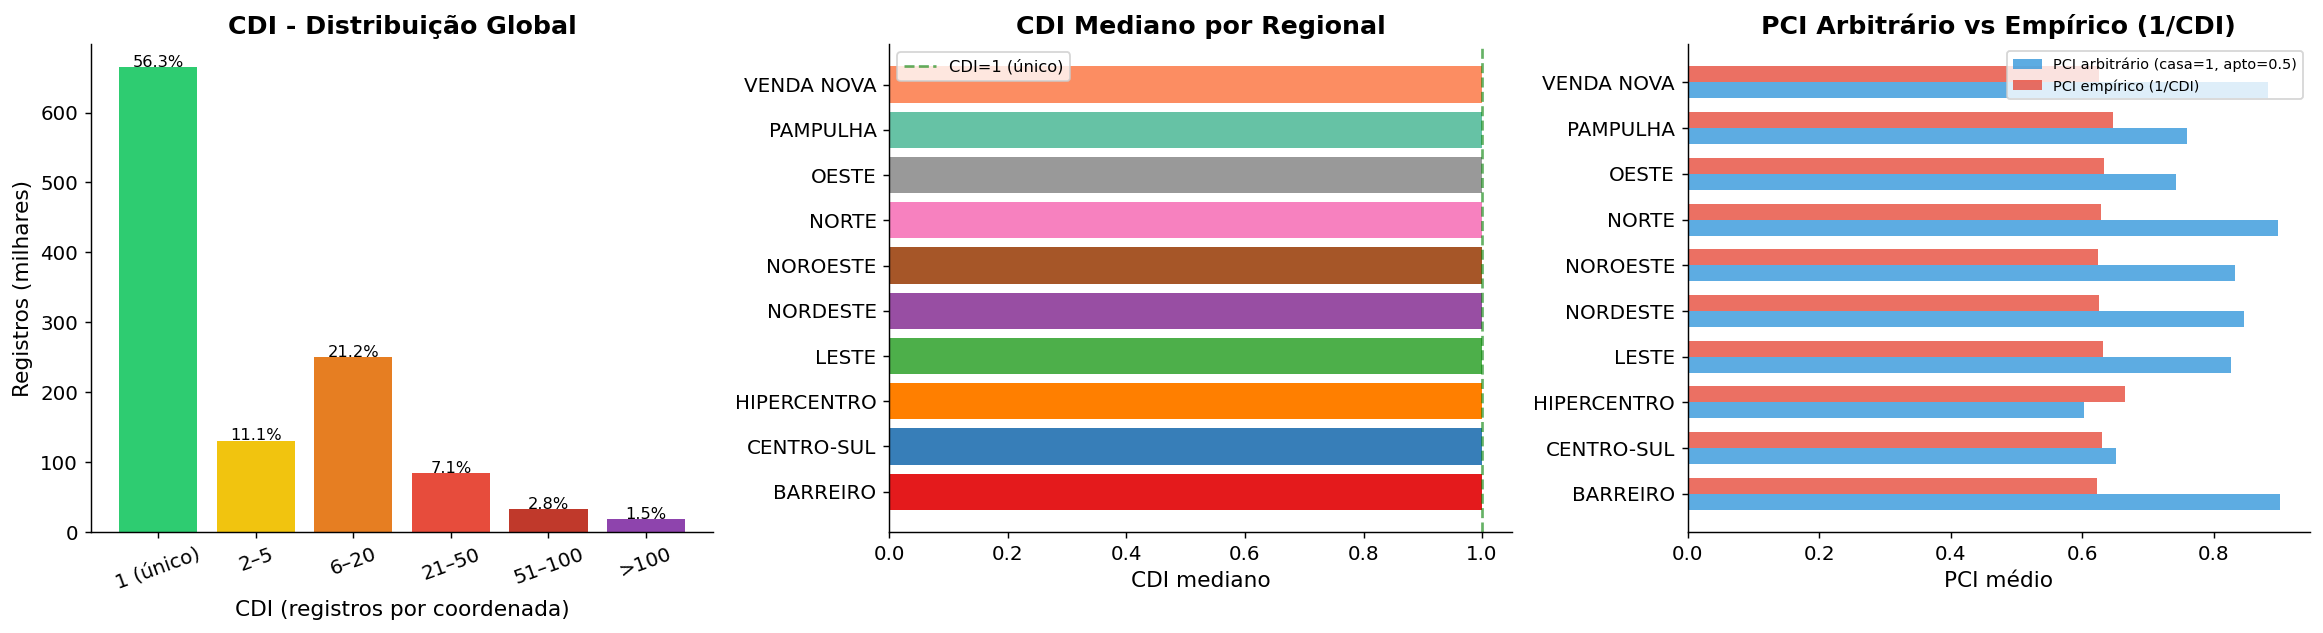

In [7]:
# 2.1 CDI — Coordinate Duplication Index
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribuição CDI (log scale)
ax = axes[0]
cdi_bins = [1, 2, 6, 21, 51, 101, coord_m['cdi'].max()+1]
cdi_labels = ['1 (único)', '2–5', '6–20', '21–50', '51–100', '>100']
cdi_cats = pd.cut(coord_m['cdi'], bins=cdi_bins, labels=cdi_labels, right=False)
cdi_vc = cdi_cats.value_counts().sort_index()
colors_cdi = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#8e44ad']
bars = ax.bar(cdi_labels, cdi_vc.values/1000, color=colors_cdi)
ax.set_xlabel('CDI (registros por coordenada)')
ax.set_ylabel('Registros (milhares)')
ax.set_title('CDI - Distribuição Global', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, cdi_vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val/len(coord_m)*100:.1f}%', ha='center', fontsize=9)

# CDI mediano por regional
ax = axes[1]
if 'NOME_REGIO' in metrics.columns:
    cdi_reg = metrics.merge(coord_m[['cdi']], left_index=True, right_index=True, how='left', suffixes=('', '_c'))
    cdi_col = 'cdi_c' if 'cdi_c' in cdi_reg.columns else 'cdi'
    cdi_by_reg = cdi_reg.groupby('NOME_REGIO')[cdi_col].median().sort_values(ascending=False)
    colors = [PALETA_REGIONAL.get(r, '#aaaaaa') for r in cdi_by_reg.index]
    ax.barh(cdi_by_reg.index, cdi_by_reg.values, color=colors)
    ax.set_xlabel('CDI mediano')
    ax.set_title('CDI Mediano por Regional', fontweight='bold')
    ax.axvline(1, color='green', linestyle='--', alpha=0.6, label='CDI=1 (único)')
    ax.legend(fontsize=9)

# PCI_empirico vs PCI_arbitrario
ax = axes[2]
x = np.arange(len(cdi_by_reg))
if 'pci_empirico' in metrics.columns:
    pci_emp = metrics.groupby('NOME_REGIO')['pci_empirico'].mean().reindex(cdi_by_reg.index)
    pci_arb = metrics.groupby('NOME_REGIO')['PCI_arbitrario'].mean().reindex(cdi_by_reg.index)
    width = 0.35
    ax.barh(x - width/2, pci_arb.values, width, label='PCI arbitrário (casa=1, apto=0.5)', color='#3498db', alpha=0.8)
    ax.barh(x + width/2, pci_emp.values, width, label='PCI empírico (1/CDI)', color='#e74c3c', alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(cdi_by_reg.index)
    ax.set_xlabel('PCI médio')
    ax.set_title('PCI Arbitrário vs Empírico (1/CDI)', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_cdi_pci.png', bbox_inches='tight')
plt.show()

CDI captura a verticalização como fenômeno de dados: edifícios de apartamentos concentram múltiplos registros na mesma coordenada GPS. Hipercentro e Centro-Sul têm CDI mediano substancialmente maior que as periferias horizontais. O PCI_empírico = 1/CDI penaliza exatamente essa concentração, de forma contínua e proporcional, diferente do PCI arbitrário de 0,5 para todos os apartamentos.

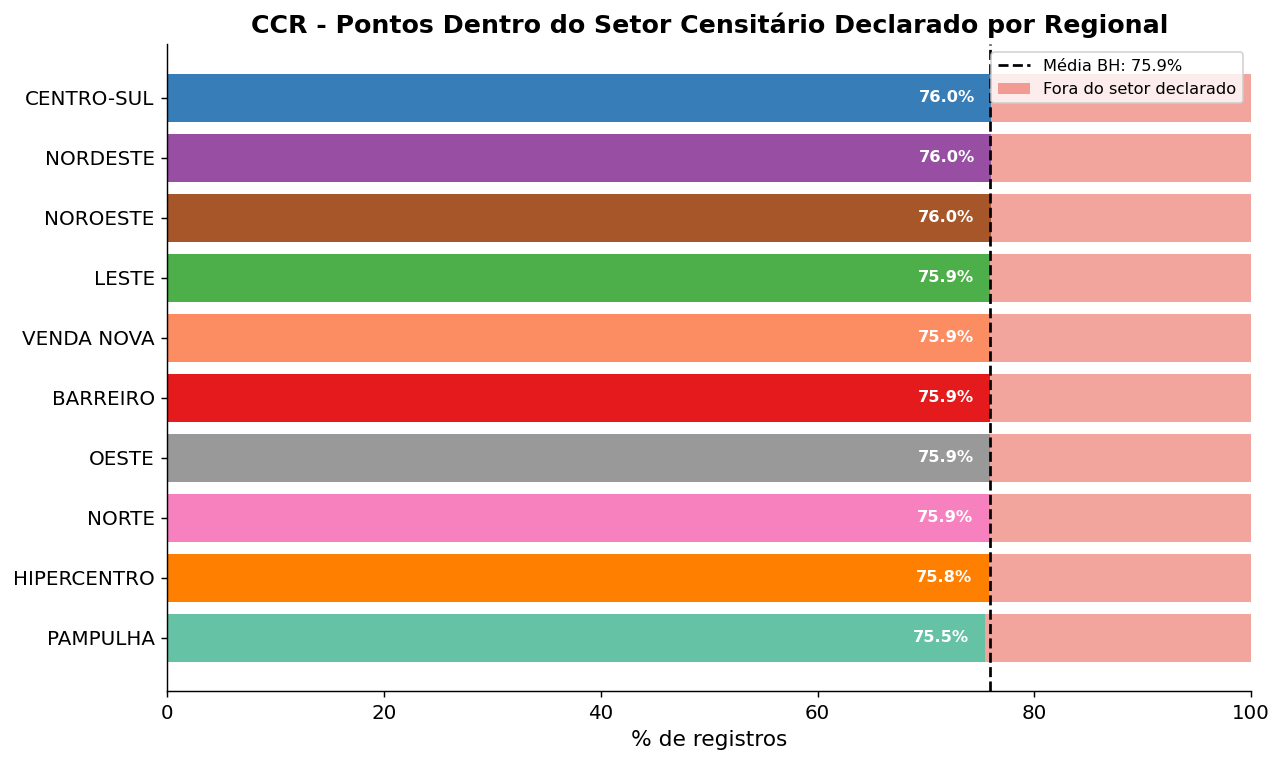

,CCR (%),N,Fora do setor (%)
NOME_REGIO,,,
PAMPULHA,75.5%,"123,924",24.5%
HIPERCENTRO,75.8%,"21,404",24.2%
NORTE,75.9%,"100,884",24.1%
OESTE,75.9%,"155,121",24.1%
BARREIRO,75.9%,"132,325",24.1%
VENDA NOVA,75.9%,"120,200",24.1%
LESTE,75.9%,"111,005",24.1%
NOROESTE,76.0%,"127,140",24.0%
NORDESTE,76.0%,"145,064",24.0%


In [8]:
# 2.2 CCR — Coordinate Containment Rate por Regional
if 'ccr' in metrics.columns and 'NOME_REGIO' in metrics.columns:
    ccr_reg = metrics.groupby('NOME_REGIO')['ccr'].agg(['mean', 'count'])
    ccr_reg['pct_fora'] = (1 - ccr_reg['mean']) * 100
    ccr_reg['pct_dentro'] = ccr_reg['mean'] * 100
    ccr_reg = ccr_reg.sort_values('pct_dentro', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [PALETA_REGIONAL.get(r, '#aaaaaa') for r in ccr_reg.index]
    bars = ax.barh(ccr_reg.index, ccr_reg['pct_dentro'].values, color=colors)
    ax.barh(ccr_reg.index, ccr_reg['pct_fora'].values,
            left=ccr_reg['pct_dentro'].values, color='#e74c3c', alpha=0.5,
            label='Fora do setor declarado')
    ax.axvline(75.9, color='black', linestyle='--', linewidth=1.5, label=f'Média BH: 75.9%')
    ax.set_xlabel('% de registros')
    ax.set_title('CCR - Pontos Dentro do Setor Censitário Declarado por Regional',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 100)

    for i, (reg, row) in enumerate(ccr_reg.iterrows()):
        ax.text(row['pct_dentro'] - 1.5, i, f"{row['pct_dentro']:.1f}%",
                va='center', ha='right', color='white', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb03_ccr_regional.png', bbox_inches='tight')
    plt.show()

    ccr_display = ccr_reg[['pct_dentro', 'count']].rename(
        columns={'pct_dentro': 'CCR (%)', 'count': 'N'})
    ccr_display['Fora do setor (%)'] = 100 - ccr_display['CCR (%)']
    display(ccr_display.round(1).style
        .background_gradient(subset=['CCR (%)'], cmap='RdYlGn', vmin=40, vmax=100)
        .background_gradient(subset=['Fora do setor (%)'], cmap='OrRd', vmin=0, vmax=60)
        .format({'CCR (%)': '{:.1f}%', 'N': '{:,.0f}', 'Fora do setor (%)': '{:.1f}%'})
        .set_caption('CCR por Regional — % de pontos dentro do setor censitário declarado'))

CCR quantifica o percentual de coordenadas dentro do setor censitário declarado. CCR < 75% em alguma regional indica coordenadas fora do setor, possível erro de geocodificação ou imprecisão do IBGE.

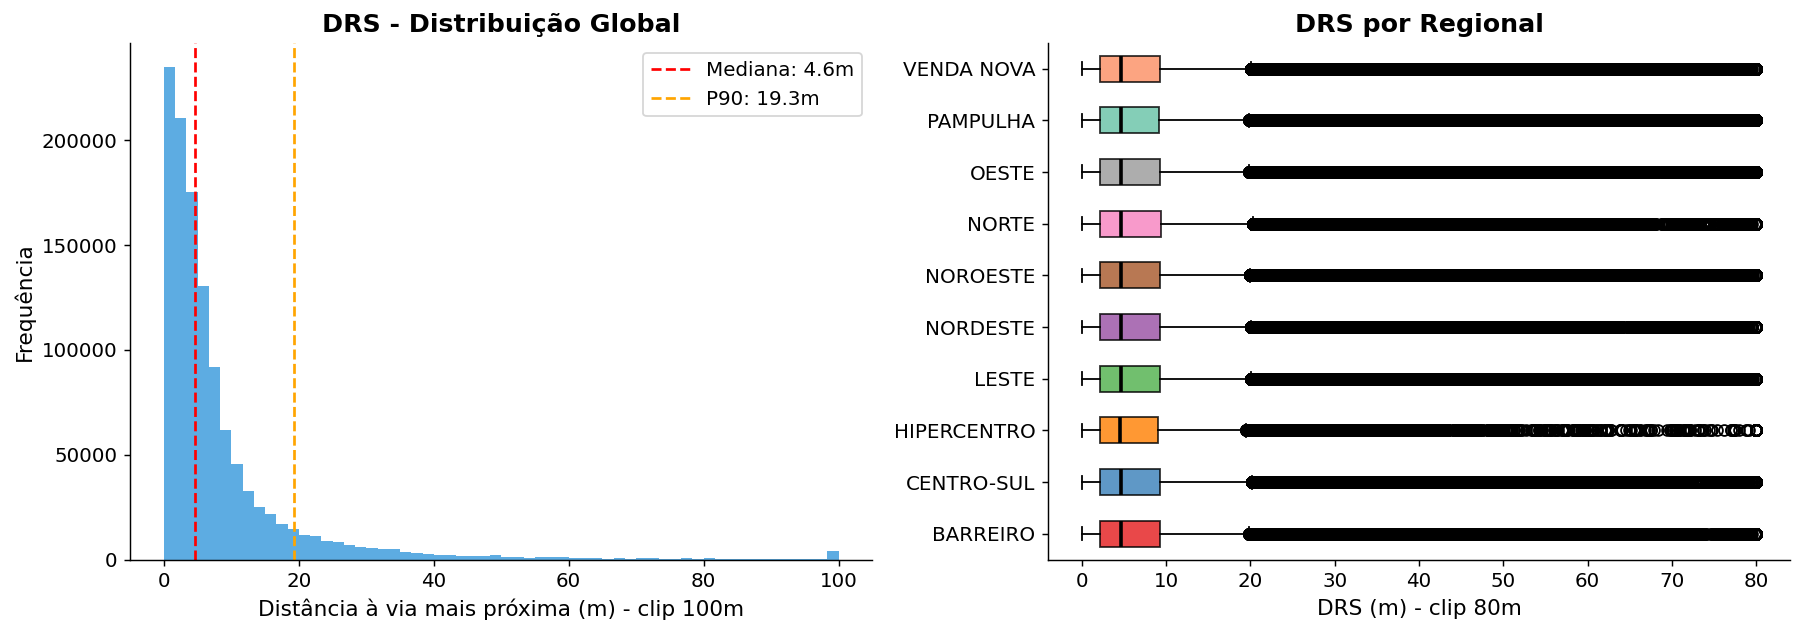

DRS global: mediana=4.6m, P90=19.3m
DRS>50m: 22,112 (1.9%)
DRS>100m: 4,062 (0.3%)


In [9]:
# 2.3 DRS — Distance to Road Segment
if 'drs' in metrics.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribuição global
    ax = axes[0]
    drs_vals = metrics['drs'].dropna()
    ax.hist(drs_vals.clip(upper=100), bins=60, color='#3498db', alpha=0.8, edgecolor='none')
    ax.axvline(drs_vals.median(), color='red', linestyle='--', label=f'Mediana: {drs_vals.median():.1f}m')
    ax.axvline(drs_vals.quantile(0.90), color='orange', linestyle='--',
               label=f'P90: {drs_vals.quantile(0.90):.1f}m')
    ax.set_xlabel('Distância à via mais próxima (m) - clip 100m')
    ax.set_ylabel('Frequência')
    ax.set_title('DRS - Distribuição Global', fontweight='bold')
    ax.legend()

    # Por regional (boxplot)
    ax = axes[1]
    if 'NOME_REGIO' in metrics.columns:
        drs_data = [metrics[metrics['NOME_REGIO'] == reg]['drs'].dropna().clip(upper=80).values
                    for reg in sorted(metrics['NOME_REGIO'].dropna().unique())]
        regs = sorted(metrics['NOME_REGIO'].dropna().unique())
        bp = ax.boxplot(drs_data, vert=False, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2})
        for patch, reg in zip(bp['boxes'], regs):
            patch.set_facecolor(PALETA_REGIONAL.get(reg, '#aaaaaa'))
            patch.set_alpha(0.8)
        ax.set_yticks(range(1, len(regs)+1))
        ax.set_yticklabels(regs)
        ax.set_xlabel('DRS (m) - clip 80m')
        ax.set_title('DRS por Regional', fontweight='bold')

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb03_drs.png', bbox_inches='tight')
    plt.show()

    print(f"DRS global: mediana={drs_vals.median():.1f}m, P90={drs_vals.quantile(0.90):.1f}m")
    print(f"DRS>50m: {(drs_vals>50).sum():,} ({(drs_vals>50).mean()*100:.1f}%)")
    print(f"DRS>100m: {(drs_vals>100).sum():,} ({(drs_vals>100).mean()*100:.1f}%)")

DRS mediana = 4,6m, a maioria dos pontos GPS está virtualmente sobre a via mais próxima, consistente com coleta em campo na porta do endereço. P90 = 19,3m; apenas 1,9% dos registros estão além de 50m de qualquer via. Esses pontos em áreas sem logradouro formal (vilas, condomínios fechados) são candidatos naturais a análise adicional.

CDI: 56,3% dos registros têm CDI=1 (casas, estabelecimentos isolados); o restante compartilha coordenada, maioria apartamentos. CCR: alta em toda BH (P25 acima de 0,90), confirmando que os endereços estão dentro do setor censitário declarado. DRS: mediana de 4,6m, P90 de 19,3m, coleta GPS em campo na porta do endereço produz pontos praticamente sobre a via.

## 1c. Tabelas Descritivas Consolidadas para a Caracterizacao

Consolida os volumes, classes, completude e distribuicoes que sustentam a
caracterizacao empirica do CNEFE. Todas as tabelas sao exportadas para
`outputs/tables/` e referenciadas no texto da dissertacao (Cap. de Metodologia,
secao de EDA). Esta e a base descritiva sobre a qual repousa a contribuicao de
caracterizacao.

In [10]:
# Tabelas descritivas consolidadas (exportadas para a dissertacao)
N = len(cnefe)

# (a) Composicao por especie
comp_esp = (cnefe['COD_ESPECIE'].value_counts().sort_index()
            .rename_axis('cod').reset_index(name='N'))
comp_esp['Especie'] = comp_esp['cod'].map(config.ESPECIE_MAP)
comp_esp['%'] = (comp_esp['N'] / N * 100).round(2)
comp_esp = comp_esp[['Especie', 'N', '%']]
comp_esp.to_csv(config.TAB_DIR / 'nb03_composicao_especie.csv', index=False)

# (b) Tipologia dos domicilios particulares
dom = cnefe[cnefe['COD_ESPECIE'] == 1]
tip = (dom['COD_TIPO_ESPECI'].value_counts().sort_index()
       .rename_axis('cod').reset_index(name='N'))
tip['Tipo'] = tip['cod'].map(config.TIPO_ESPECIE_MAP)
tip['%'] = (tip['N'] / len(dom) * 100).round(1)
tip = tip[['Tipo', 'N', '%']]
tip.to_csv(config.TAB_DIR / 'nb03_tipologia_domicilio.csv', index=False)

# (c) Nivel de coleta (NV_GEO_COORD)
nvt = (cnefe['NV_GEO_COORD'].value_counts().sort_index()
       .rename_axis('cod').reset_index(name='N'))
nvt['Nivel'] = nvt['cod'].map(config.NV_GEO_MAP)
nvt['%'] = (nvt['N'] / N * 100).round(2)
nvt = nvt[['Nivel', 'N', '%']]
nvt.to_csv(config.TAB_DIR / 'nb03_nivel_coleta.csv', index=False)

# (d) Completude dos campos de enderecamento
campos = ['LOGRAD_NUM', 'COMPLEMENTO', 'CEP', 'DSC_LOCALIDADE', 'DSC_ESTABELECIMENTO']
rows = []
for col in campos:
    if col in cnefe.columns:
        s = cnefe[col].astype('string').str.strip()
        pct = ((cnefe[col].notna()) & (s != '') & (s.str.lower() != 'nan')).mean() * 100
        rows.append({'Campo': col, '% preenchido': round(pct, 1)})
completude = pd.DataFrame(rows)
completude.to_csv(config.TAB_DIR / 'nb03_completude.csv', index=False)

# (e) Quantis das metricas intrinsecas continuas (CDI, DRS)
def _q(s):
    s = pd.to_numeric(s, errors='coerce').dropna()
    return {'N': len(s), 'Media': round(s.mean(), 2), 'P25': round(s.quantile(.25), 2),
            'P50': round(s.median(), 2), 'P75': round(s.quantile(.75), 2),
            'P90': round(s.quantile(.90), 2), 'P95': round(s.quantile(.95), 2)}
metr = pd.DataFrame({'CDI': _q(cdi_df['cdi']), 'DRS (m)': _q(drs)}).T
metr = metr.reset_index().rename(columns={'index': 'Metrica'})
metr.to_csv(config.TAB_DIR / 'nb03_metricas_intrinsecas_quantis.csv', index=False)

# (f) Colapso de coordenadas e contencao no setor (CCR)
cdi_s = cdi_df['cdi']
resumo = pd.DataFrame({
    'Indicador': ['CDI=1 (coordenada unica)', 'CDI>=10', 'CDI>=50', 'CDI maximo',
                  'CCR (dentro do setor declarado)', 'DRS mediana (m)'],
    'Valor': [f"{(cdi_s == 1).mean()*100:.1f}%", f"{(cdi_s >= 10).mean()*100:.1f}%",
              f"{(cdi_s >= 50).mean()*100:.1f}%", f"{int(cdi_s.max())}",
              f"{float(ccr.mean())*100:.1f}%", f"{float(pd.to_numeric(drs, errors='coerce').median()):.2f}"]})
resumo.to_csv(config.TAB_DIR / 'nb03_colapso_coordenadas.csv', index=False)

print("Tabelas descritivas exportadas para outputs/tables/ (nb03_*.csv)")
for _df in [comp_esp, tip, nvt, completude, metr, resumo]:
    display(_df)


Tabelas descritivas exportadas para outputs/tables/ (nb03_*.csv)


,Especie,N,%
0,Domicílio Particular,1025822,86.93
1,Domicílio Coletivo,1348,0.11
2,Estab. Agropecuário,42,0.00
3,Estab. Ensino,2037,0.17
4,Estab. Saúde,2483,0.21
5,Outras Finalidades,125268,10.62
6,Em Construção,19297,1.64
7,Estab. Religioso,3805,0.32


,Tipo,N,%
0,Casa,585221,57.0
1,Casa de Vila/Condomínio,26302,2.6
2,Apartamento,403623,39.3
3,Outros,10676,1.0


,Nivel,N,%
0,Medido em campo,994242,84.25
1,Estimado próximo,173799,14.73
2,Estimado distante,8306,0.70
3,Outro método,3752,0.32
4,Sem medição,3,0.00


,Campo,% preenchido
0,LOGRAD_NUM,100.0
1,COMPLEMENTO,58.5
2,CEP,100.0
3,DSC_LOCALIDADE,100.0
4,DSC_ESTABELECIMENTO,11.4


,Metrica,N,Media,P25,P50,P75,P90,P95
0,CDI,1180102.0,9.88,1.00,1.00,9.00,24.00,46.00
1,DRS (m),1180102.0,8.60,2.11,4.63,9.26,19.26,29.77


,Indicador,Valor
0,CDI=1 (coordenada unica),56.3%
1,CDI>=10,24.6%
2,CDI>=50,4.4%
3,CDI maximo,287
4,CCR (dentro do setor declarado),75.9%
5,DRS mediana (m),4.63


## 3. Caracterização do BHMap: Padrão-Ouro Filtrado

### 3.1 Validade do BHMap como Referência

Antes de usar o BHMap como padrão-ouro, verificamos a distribuição de `SITUACAO_P` (situação do lote/endereço) para garantir que apenas registros com localização geograficamente confirmada entram na análise de erro posicional.

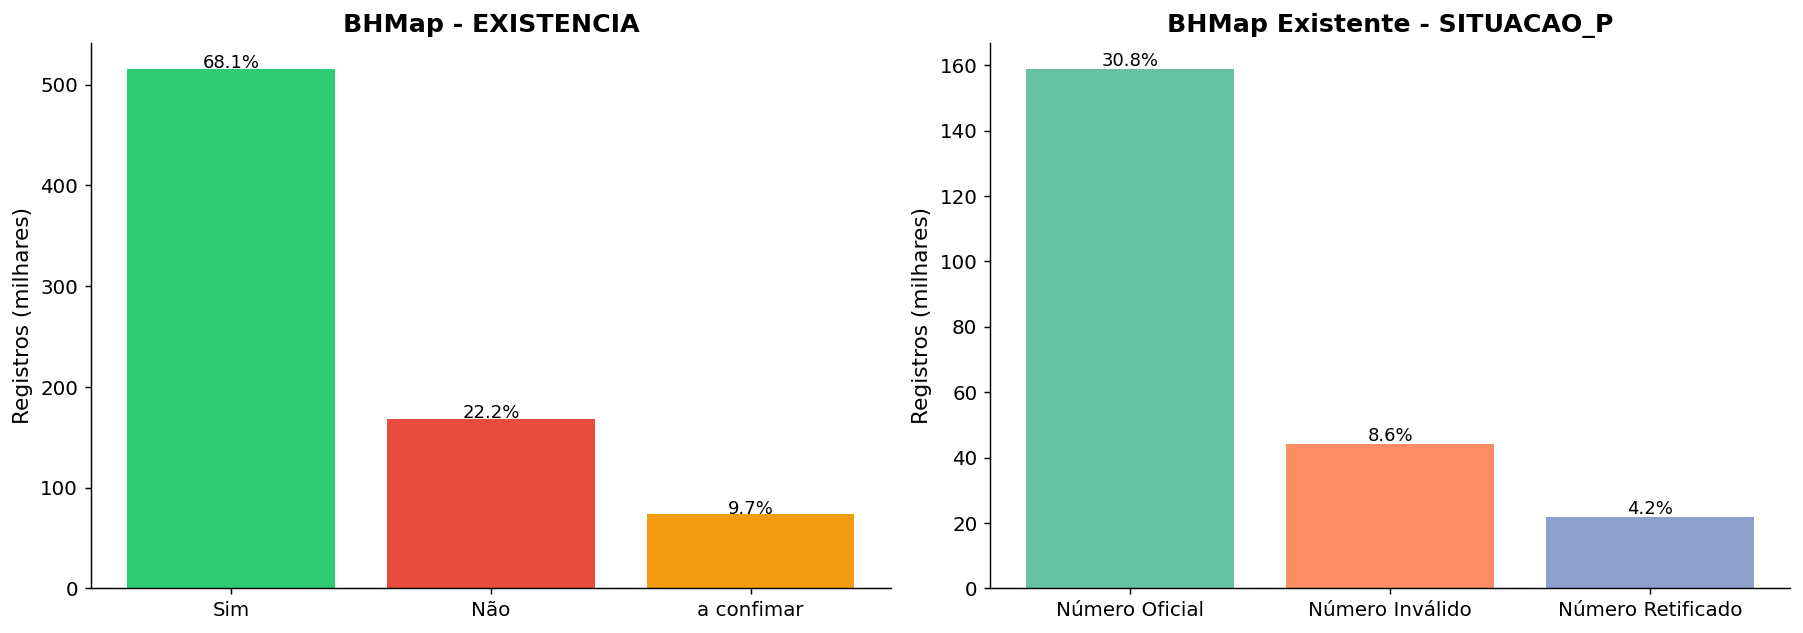

In [11]:
# 3.1 SITUACAO_P no BHMap existente
bhmap_full = gpd.read_parquet(config.PROCESSED_DIR / 'bhmap_bh.parquet')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EXISTENCIA
ax = axes[0]
ex_vc = bhmap_full['EXISTENCIA'].value_counts()
colors_ex = {'Sim': '#2ecc71', 'Não': '#e74c3c', 'a confimar': '#f39c12'}
bars = ax.bar(ex_vc.index, ex_vc.values/1000,
              color=[colors_ex.get(k, '#aaaaaa') for k in ex_vc.index])
ax.set_ylabel('Registros (milhares)')
ax.set_title('BHMap - EXISTENCIA', fontweight='bold')
for bar, val in zip(bars, ex_vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val/len(bhmap_full)*100:.1f}%', ha='center', fontsize=10)

# SITUACAO_P
ax = axes[1]
sit_vc = bhmap_exist['SITUACAO_P'].value_counts()
bars = ax.bar(sit_vc.index, sit_vc.values/1000,
              color=sns.color_palette('Set2', len(sit_vc)))
ax.set_ylabel('Registros (milhares)')
ax.set_title('BHMap Existente - SITUACAO_P', fontweight='bold')
for bar, val in zip(bars, sit_vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val/len(bhmap_exist)*100:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_bhmap_qualidade.png', bbox_inches='tight')
plt.show()

A distribuição de SITUACAO_P confirma a qualidade da base de referência: apenas registros com EXISTENCIA=Sim são usados como padrão-ouro, evitando comparação contra endereços inexistentes.

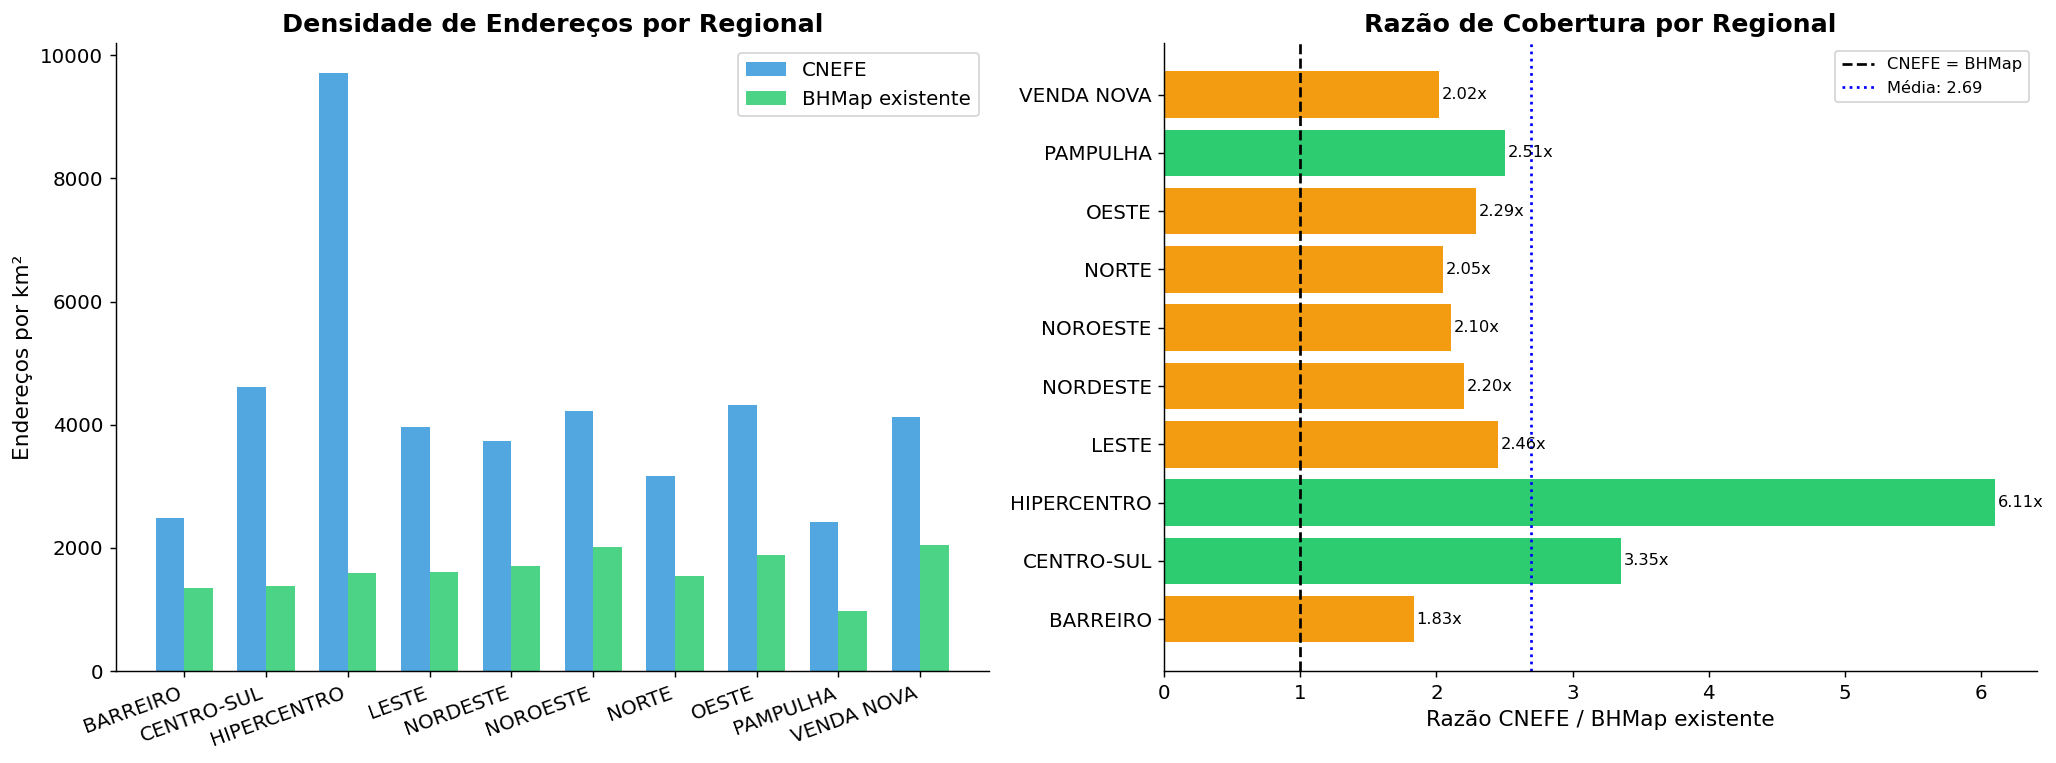

,CNEFE (N),BHMap (N),Razão CNEFE/BHMap
NOME_REGIO,,,
BARREIRO,"132,701","72,351",1.83x
CENTRO-SUL,"136,439","40,685",3.35x
HIPERCENTRO,"21,440","3,510",6.11x
LESTE,"110,574","45,035",2.46x
NORDESTE,"147,118","66,752",2.20x
NOROESTE,"127,133","60,416",2.10x
NORTE,"103,224","50,316",2.05x
OESTE,"155,185","67,814",2.29x
PAMPULHA,"123,907","49,434",2.51x


In [12]:
# 3.2 Densidade por regional: CNEFE vs BHMap existente
regionais_proj = regionais.to_crs(config.TARGET_CRS)
regionais_proj['area_km2'] = regionais_proj.geometry.area / 1e6

# Contagem de pontos por regional (spatial join)
cnefe_counts = gpd.sjoin(cnefe, regionais_proj[['NOME_REGIO', 'area_km2', 'geometry']],
                          how='left', predicate='within')
cnefe_counts = cnefe_counts[~cnefe_counts.index.duplicated(keep='first')]
cnefe_by_reg = cnefe_counts.groupby('NOME_REGIO').size().rename('n_cnefe')

bhmap_counts = gpd.sjoin(bhmap_exist, regionais_proj[['NOME_REGIO', 'area_km2', 'geometry']],
                          how='left', predicate='within')
bhmap_counts = bhmap_counts[~bhmap_counts.index.duplicated(keep='first')]
bhmap_by_reg = bhmap_counts.groupby('NOME_REGIO').size().rename('n_bhmap')

area_by_reg = regionais_proj.set_index('NOME_REGIO')['area_km2']

compare_df = pd.concat([cnefe_by_reg, bhmap_by_reg, area_by_reg], axis=1).dropna()
compare_df['cnefe_por_km2'] = compare_df['n_cnefe'] / compare_df['area_km2']
compare_df['bhmap_por_km2'] = compare_df['n_bhmap'] / compare_df['area_km2']
compare_df['razao_cnefe_bhmap'] = compare_df['n_cnefe'] / compare_df['n_bhmap']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Densidade por km²
ax = axes[0]
x = np.arange(len(compare_df))
width = 0.35
ax.bar(x - width/2, compare_df['cnefe_por_km2'], width, label='CNEFE', color='#3498db', alpha=0.85)
ax.bar(x + width/2, compare_df['bhmap_por_km2'], width, label='BHMap existente', color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, rotation=20, ha='right')
ax.set_ylabel('Endereços por km²')
ax.set_title('Densidade de Endereços por Regional', fontweight='bold')
ax.legend()

# Razão CNEFE/BHMap
ax = axes[1]
colors = ['#e74c3c' if r < 1.5 else '#f39c12' if r < 2.5 else '#2ecc71'
          for r in compare_df['razao_cnefe_bhmap']]
bars = ax.barh(compare_df.index, compare_df['razao_cnefe_bhmap'], color=colors)
ax.axvline(1, color='black', linestyle='--', linewidth=1.5, label='CNEFE = BHMap')
ax.axvline(compare_df['razao_cnefe_bhmap'].mean(), color='blue', linestyle=':',
           linewidth=1.5, label=f'Média: {compare_df["razao_cnefe_bhmap"].mean():.2f}')
ax.set_xlabel('Razão CNEFE / BHMap existente')
ax.set_title('Razão de Cobertura por Regional', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, compare_df['razao_cnefe_bhmap']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}x', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_cobertura_regional.png', bbox_inches='tight')
plt.show()

cov_display = compare_df[['n_cnefe', 'n_bhmap', 'razao_cnefe_bhmap']].round(2)
cov_display.columns = ['CNEFE (N)', 'BHMap (N)', 'Razão CNEFE/BHMap']
display(cov_display.style
    .background_gradient(subset=['Razão CNEFE/BHMap'], cmap='RdYlGn', vmin=1, vmax=4)
    .format({'CNEFE (N)': '{:,.0f}', 'BHMap (N)': '{:,.0f}', 'Razão CNEFE/BHMap': '{:.2f}x'})
    .set_caption('Cobertura por Regional: CNEFE vs BHMap existente'))

Compara a densidade de pontos CNEFE vs pontos BHMap existentes por regional, revelando onde o CNEFE é mais denso que o BHMap (sinal de endereços sem par) e vice-versa.

---
## 4. Distribuição Espacial: Mapas Coropléticos por Setor Censitário

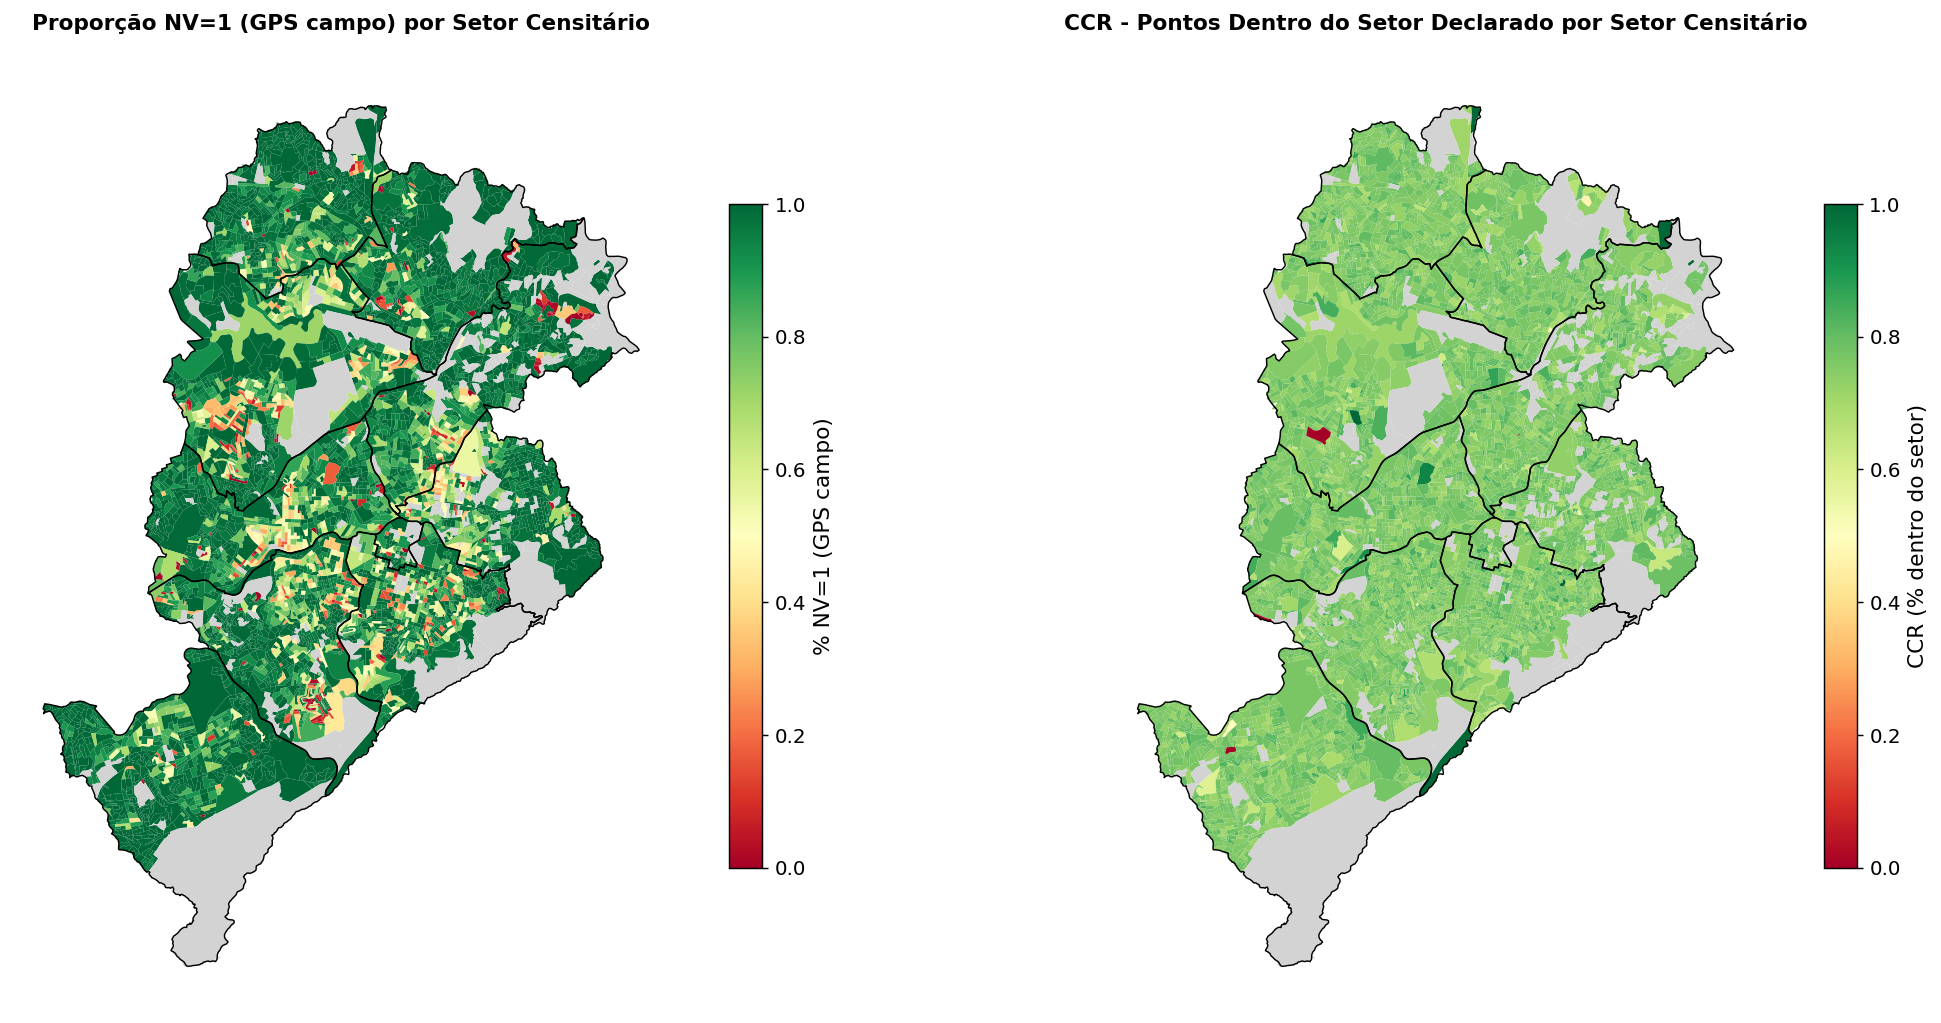

In [13]:
# 4.1 Mapa: proporção NV=1 (GPS campo) por setor censitário
cnefe_setor = cnefe.copy()
cnefe_setor['nv1'] = (cnefe_setor['NV_GEO_COORD'] == 1).astype(int)
nv1_by_setor = cnefe_setor.groupby('COD_SETOR').agg(
    n=('nv1', 'count'),
    pct_nv1=('nv1', 'mean')
).reset_index()

# Normalizar COD_SETOR para join
nv1_by_setor['COD_SETOR_norm'] = nv1_by_setor['COD_SETOR'].str.rstrip('P').str.rstrip('S')
setores_plot = setores.merge(nv1_by_setor[['COD_SETOR_norm', 'n', 'pct_nv1']],
                              left_on='COD_SETOR', right_on='COD_SETOR_norm', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
setores_plot.plot(column='pct_nv1', cmap='RdYlGn', legend=True, ax=ax,
                   missing_kwds={'color': 'lightgray', 'label': 'Sem dados'},
                   legend_kwds={'label': '% NV=1 (GPS campo)', 'shrink': 0.7})
regionais_proj.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('Proporção NV=1 (GPS campo) por Setor Censitário', fontweight='bold', fontsize=12)
ax.axis('off')

# 4.2 Mapa: CCR (containment no setor) por setor
# Usar metrics_v2 que tem ccr e COD_SETOR
ccr_setor_df = metrics[['COD_SETOR', 'ccr']].dropna()
ccr_by_setor = ccr_setor_df.groupby('COD_SETOR').agg(
    ccr_pct=('ccr', 'mean'),
    n=('ccr', 'count')
).reset_index()
ccr_by_setor['COD_SETOR_norm'] = ccr_by_setor['COD_SETOR'].str.rstrip('P').str.rstrip('S')

setores_ccr = setores.merge(ccr_by_setor[['COD_SETOR_norm', 'ccr_pct']],
                             left_on='COD_SETOR', right_on='COD_SETOR_norm', how='left')

ax = axes[1]
setores_ccr.plot(column='ccr_pct', cmap='RdYlGn', legend=True, ax=ax,
                  missing_kwds={'color': 'lightgray', 'label': 'Sem dados'},
                  legend_kwds={'label': 'CCR (% dentro do setor)', 'shrink': 0.7})
regionais_proj.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('CCR - Pontos Dentro do Setor Declarado por Setor Censitário',
             fontweight='bold', fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_mapas_nv1_ccr.png', bbox_inches='tight', dpi=150)
plt.show()

`EXISTENCIA='Sim'` reduziu o BHMap em ~32% (756K → 515K pontos). A filtragem é crítica, endereços não-existentes introduziriam falsos positivos no pipeline de matching. A distribuição por regional é uniforme, sem viés geográfico do filtro.

## Conclusão do Notebook 03

A EDA das duas bases (CNEFE e BHMap) e o cálculo das métricas intrínsecas estabeleceram a base empírica do índice GCI sem recurso a padrão-ouro externo:

- **CDI** revela a verticalização como fenômeno de dados (Hipercentro mediano = 55; Barreiro = 1), motivando o PCI_empirico = 1/CDI.
- **CCR** mede o descasamento entre coordenada GPS e setor censitário declarado (global = 75,9%), independente do BHMap.
- **DRS** confirma forte aderência à rede viária (mediana = 4,6m; 98,1% dentro de 50m), um proxy posicional intrínseco.
- A caracterização do BHMap filtrado (`EXISTENCIA='Sim'`) delimita o padrão-ouro usado nas métricas extrínsecas dos NB05 e NB07.

A EDA das camadas de contexto BHMap e o screening de covariáveis seguem no **NB08**, que operacionaliza o contexto urbano para as hipóteses contextuais (H4 em diante) testadas nos NB09 a NB12.